In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix,classification_report
import xgboost as xgb
from xgboost import XGBClassifier

In [2]:
df=pd.read_csv('/kaggle/input/heart-failure-dataset/heart.csv')
print(df.shape)

(918, 12)


In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [5]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [7]:
df.columns=df.columns.str.lower()

In [8]:
missing=['restingbp','cholesterol']
for m in missing:
    no_zero=(df[m]==0).sum()
    print(m,no_zero)

restingbp 1
cholesterol 172


In [9]:
df['restingbp'] = df['restingbp'].replace(0,np.nan)
df['restingbp']=df['restingbp'].fillna(df['restingbp'].median())

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='cholesterol', ylabel='Count'>

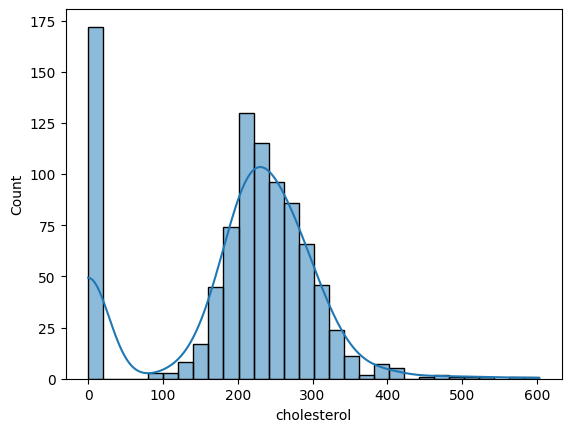

In [10]:
sns.histplot(df['cholesterol'].dropna(), bins=30, kde=True)

In [11]:
df['cholesterol'] = df['cholesterol'].replace(0,np.nan)
df['cholesterol']=df['cholesterol'].fillna(df['cholesterol'].median())

In [12]:
df.describe()

,age,restingbp,cholesterol,fastingbs,maxhr,oldpeak,heartdisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.538126,243.204793,0.233115,136.809368,0.887364,0.553377
std,9.432617,17.990127,53.401297,0.423046,25.460334,1.066570,0.497414
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,237.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [13]:
missing=['restingbp','cholesterol']
for m in missing:
    no_zero=(df[m]==0).sum()
    print(m,no_zero)

restingbp 0
cholesterol 0


In [14]:
categorical=['sex','chestpaintype','restingecg','exerciseangina','st_slope']
for c in categorical:
    print(c, df[c].value_counts())

sex sex
M    725
F    193
Name: count, dtype: int64
chestpaintype chestpaintype
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
restingecg restingecg
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
exerciseangina exerciseangina
N    547
Y    371
Name: count, dtype: int64
st_slope st_slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


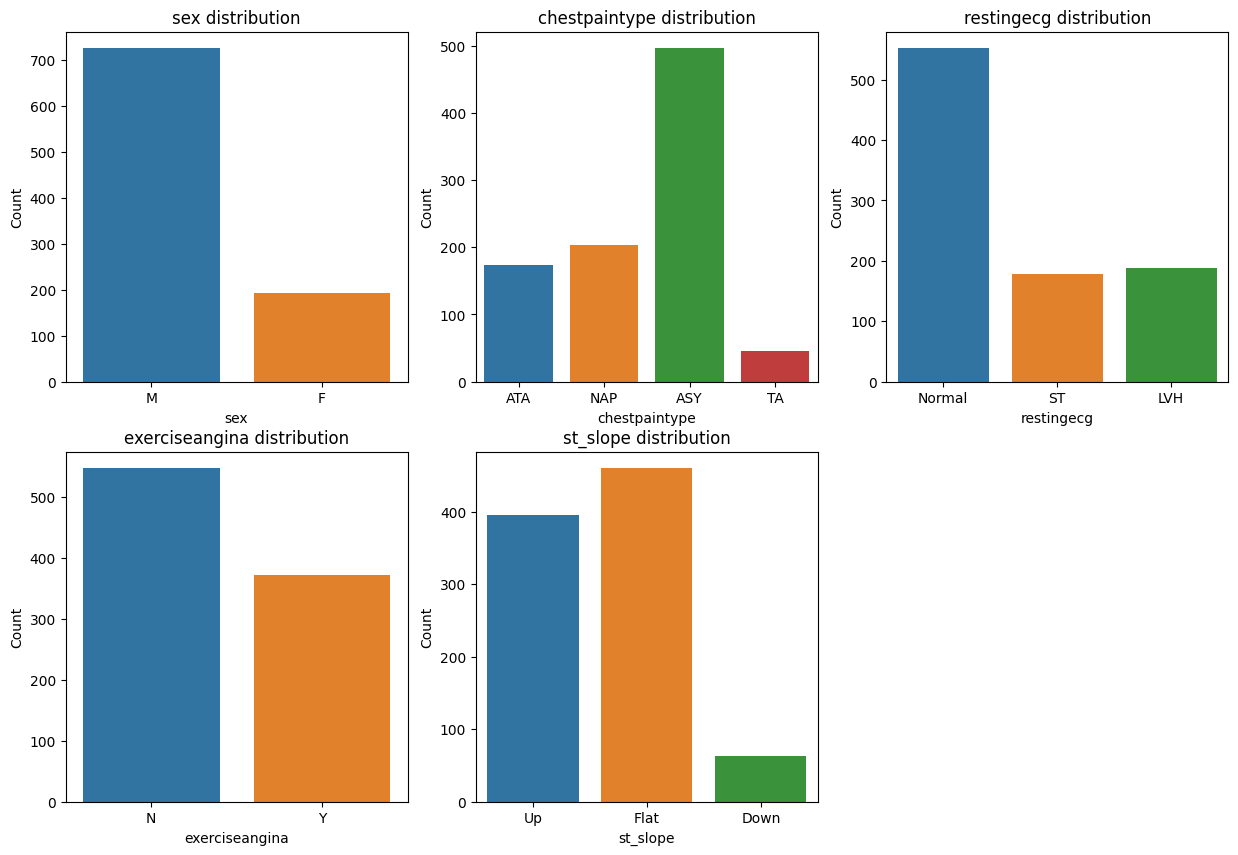

In [15]:
plt.figure(figsize=(15, 10))
for i, c in enumerate(categorical,1):
    plt.subplot(2,3,i)
    sns.countplot(data=df,x=c)
    plt.title(f'{c} distribution')
    plt.xlabel(c)
    plt.ylabel('Count')

plt.show()

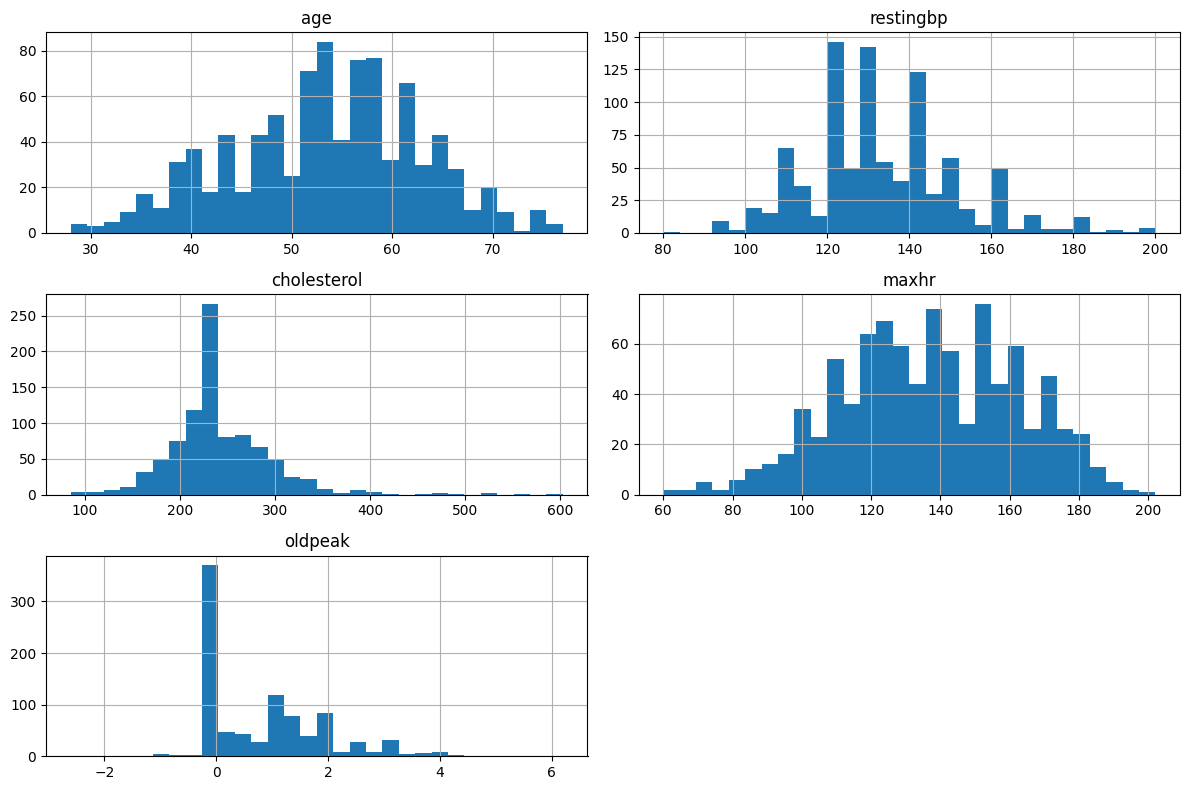

In [16]:
numerical = ['age','restingbp','cholesterol','maxhr','oldpeak']
df[numerical].hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

In [17]:
df['heartdisease'].value_counts()

heartdisease
1    508
0    410
Name: count, dtype: int64

Text(0.5, 1.0, 'Target distribution (0=no disease,1=disease)')

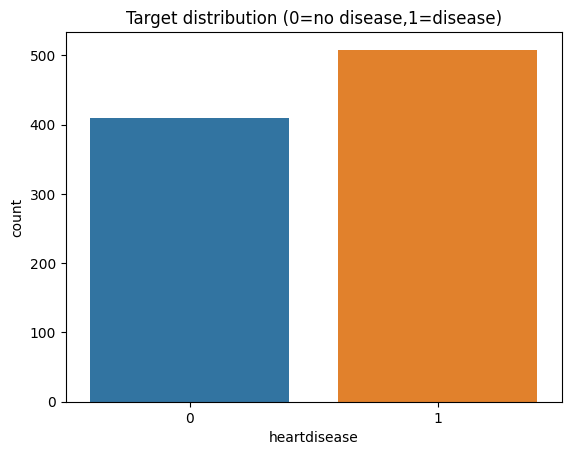

In [18]:
sns.countplot(x='heartdisease', data=df)
plt.title("Target distribution (0=no disease,1=disease)")

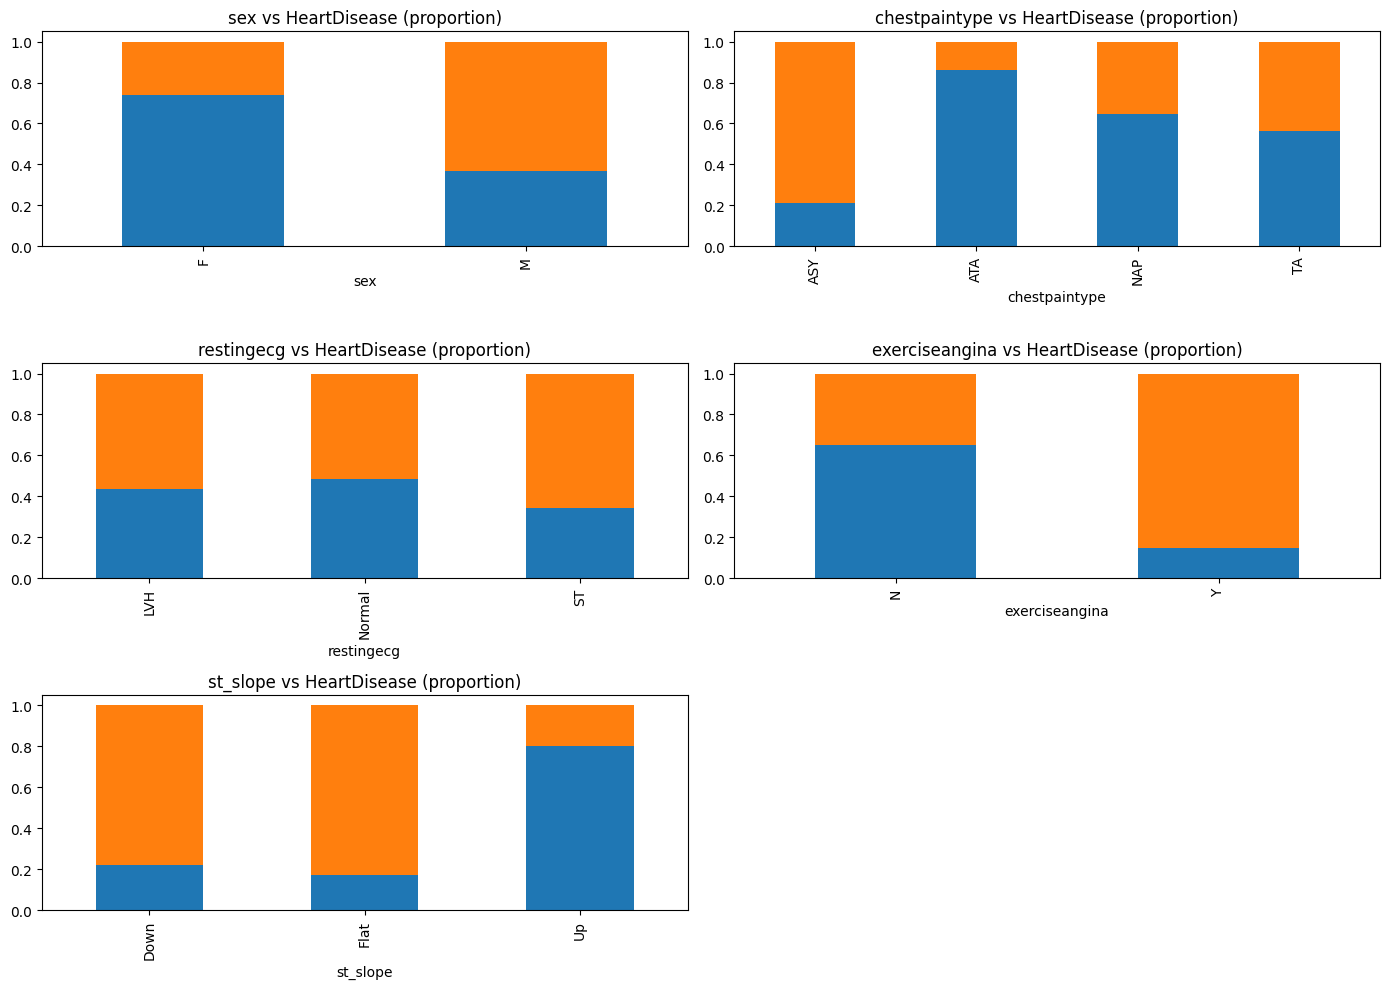

In [19]:
plt.figure(figsize=(14,10))
for i, c in enumerate(categorical,1):
    plt.subplot(3,2,i)
    prop = pd.crosstab(df[c], df['heartdisease'], normalize='index')
    prop.plot(kind='bar', stacked=True, ax=plt.gca(), legend=False)
    plt.title(f"{c} vs HeartDisease (proportion)")
plt.tight_layout()
plt.show()

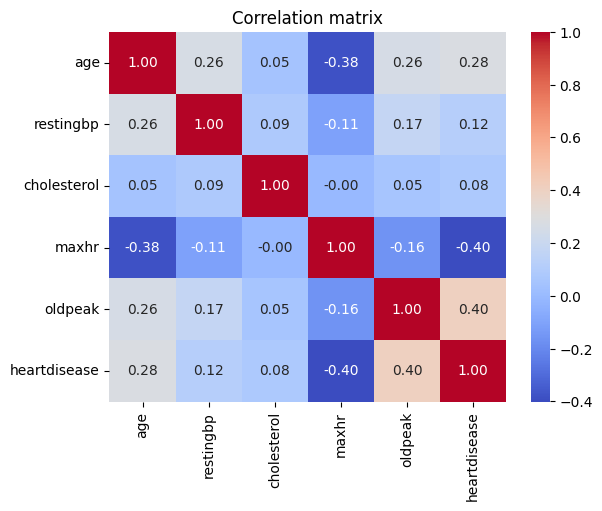

In [20]:
sns.heatmap(df[numerical + ['heartdisease']].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

In [21]:
df_full_train,df_test=train_test_split(df,test_size=0.2,random_state=42,
                                          stratify=df['heartdisease'])
df_train,df_val=train_test_split(df_full_train,test_size=0.25,random_state=42,
                                          stratify=df_full_train['heartdisease'])

In [22]:
df_train=df_train.reset_index(drop=True)
df_val=df_val.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)

In [23]:
y_train=df_train['heartdisease'].values
y_val=df_val['heartdisease'].values
y_test=df_test['heartdisease'].values

In [24]:
del df_train['heartdisease']
del df_val['heartdisease']
del df_test['heartdisease']

In [25]:
dv=DictVectorizer(sparse=False)
train_dicts=df_train.fillna(0).to_dict(orient='records')
X_train=dv.fit_transform(train_dicts)

val_dicts=df_val.fillna(0).to_dict(orient='records')
X_val=dv.transform(val_dicts)

In [26]:
def eval_model(model,X_train,y_train,X_val,y_val):
    y_pred=model.predict(X_val)
    y_pred_proba=model.predict_proba(X_val)[:,1]

    acc=accuracy_score(y_val,y_pred)
    prec=precision_score(y_val,y_pred)
    rec=recall_score(y_val,y_pred)
    f1=f1_score(y_val,y_pred)
    auc=roc_auc_score(y_val,y_pred_proba)

    print(f"accuracy: {acc:.3f}")
    print(f"precision: {prec:.3f}")
    print(f"recall: {rec:.3f}")
    print(f"f1: {f1:.3f}")
    print(f"roc-auc: {auc:.3f}")

    cm=confusion_matrix(y_val,y_pred)
    sns.heatmap(cm,annot=True,fmt='d')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(type(model).__name__)
    plt.show()

    return {'acc':acc,'prec':prec,'rec':rec,'f1':f1,'auc':auc}

## baseline model

## logistics regression

accuracy: 0.799
precision: 0.822
recall: 0.814
f1: 0.818
roc-auc: 0.896


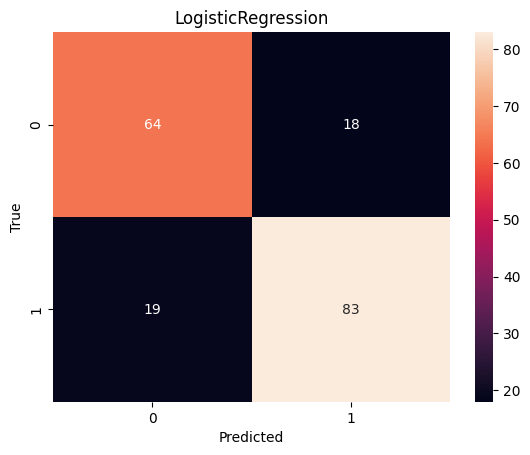

In [27]:
lr=LogisticRegression(max_iter=1000,solver='liblinear')
lr.fit(X_train,y_train)

baseline_metrics=eval_model(lr,X_train,y_train,X_val,y_val)


## decision trees

best_params {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 15, 'min_samples_split': 2}
accuracy: 0.842
precision: 0.861
recall: 0.853
f1: 0.857
roc-auc: 0.876


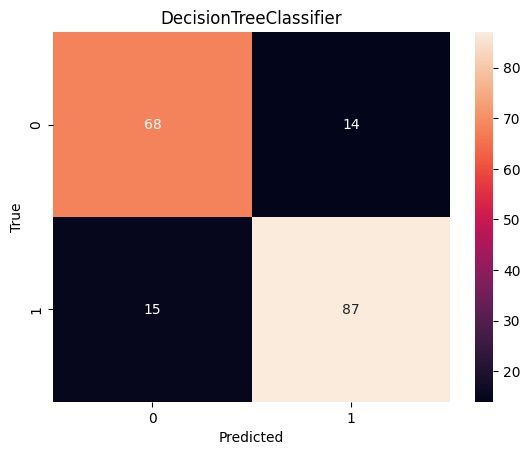

In [28]:
dt_params={'max_depth':[1,3,5,6,7,8,9,10,20,None],
          'min_samples_split':[2,5,10],
          'min_samples_leaf':[1,2,5,10,15,20,50,100,200,500,1000],
          'criterion': ['gini', 'entropy']}
dt=DecisionTreeClassifier(random_state=42)
dt_cv=GridSearchCV(dt,dt_params,cv=5,scoring='roc_auc',n_jobs=-1)
dt_cv.fit(X_train,y_train)

print('best_params',dt_cv.best_params_)
dt_best=dt_cv.best_estimator_
dt_metrics=eval_model(dt_best,X_train,y_train,X_val,y_val)

## random forest

best_params {'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 300}
accuracy: 0.815
precision: 0.833
recall: 0.833
f1: 0.833
roc-auc: 0.901


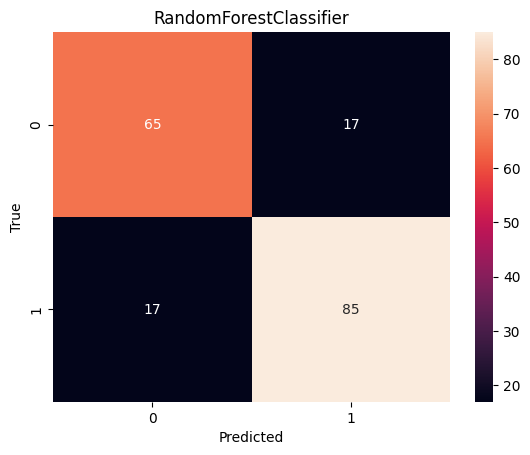

In [29]:
rf_params={'max_depth':[5,10,15,20,None],
          'n_estimators':[50,100,150,200,300],
          'min_samples_leaf':[1,3,5,10,20]}

rf=RandomForestClassifier(random_state=42,n_jobs=-1)
rf_cv=GridSearchCV(rf,rf_params,cv=5,scoring='roc_auc',n_jobs=-1)
rf_cv.fit(X_train,y_train)

print('best_params',rf_cv.best_params_)
rf_best=rf_cv.best_estimator_
rf_metrics=eval_model(rf_best,X_train,y_train,X_val,y_val)

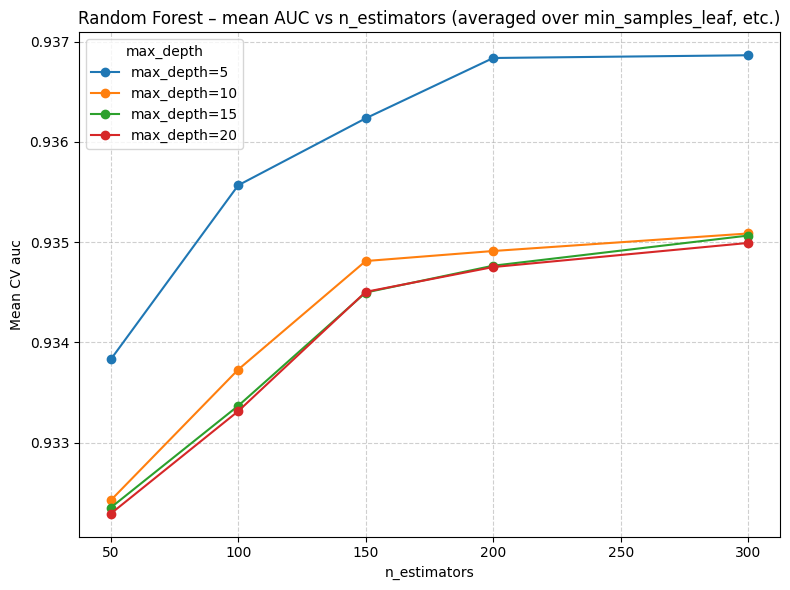

In [30]:
df_rf=pd.DataFrame(rf_cv.cv_results_)

agg=(
    df_rf.groupby(['param_max_depth', 'param_n_estimators'])
    ['mean_test_score']
    .mean()
    .reset_index())

plt.figure(figsize=(8,6))
for depth,subset in agg.groupby('param_max_depth'):
    plt.plot(
        subset['param_n_estimators'],
        subset['mean_test_score'],
        marker='o',
        label=f"max_depth={depth}")

plt.xlabel('n_estimators')
plt.ylabel('Mean CV auc')
plt.title('Random Forest – mean AUC vs n_estimators (averaged over min_samples_leaf, etc.)')
plt.legend(title='max_depth')
plt.grid(True,linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()


## gradient boosting

best params: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 400}
accuracy: 0.821
precision: 0.856
recall: 0.814
f1: 0.834
roc-auc: 0.906


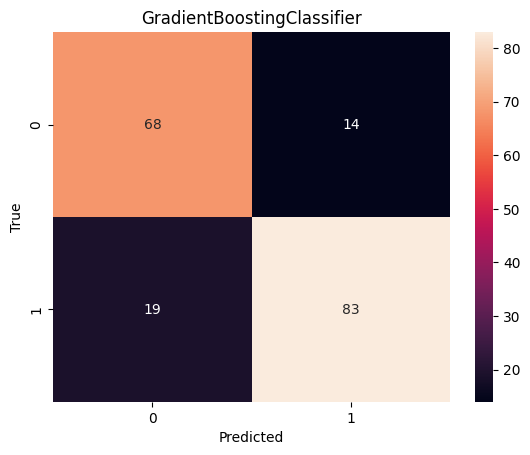

In [31]:
gb_params = {'n_estimators':[50,100,200,300,400],
             'learning_rate':[0.01,0.05,0.1,1],
             'max_depth':[2,3,4,5,10,15,20]}

gb=GradientBoostingClassifier(random_state=42)
gb_cv=GridSearchCV(gb,gb_params,cv=5,scoring='roc_auc',n_jobs=-1)
gb_cv.fit(X_train,y_train)

print("best params:",gb_cv.best_params_)
gb_best=gb_cv.best_estimator_
gb_metrics=eval_model(gb_best,X_train,y_train,X_val,y_val)

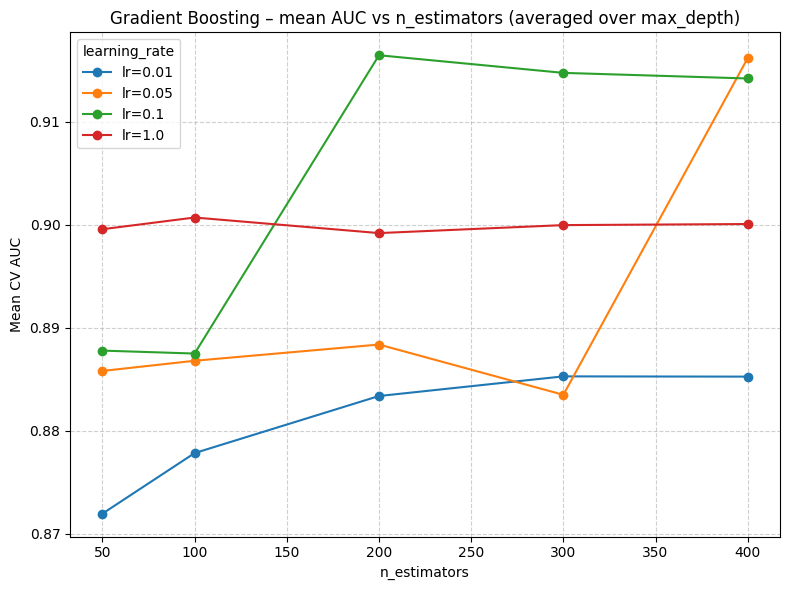

In [32]:
df_gb = pd.DataFrame(gb_cv.cv_results_)

# aggregate across depths to smooth the lines
agg = (
    df_gb.groupby(['param_learning_rate', 'param_n_estimators'])
    ['mean_test_score']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,6))
for lr, subset in agg.groupby('param_learning_rate'):
    plt.plot(
        subset['param_n_estimators'],
        subset['mean_test_score'],
        marker='o',
        label=f"lr={lr}"
    )

plt.xlabel('n_estimators')
plt.ylabel('Mean CV AUC')
plt.title('Gradient Boosting – mean AUC vs n_estimators (averaged over max_depth)')
plt.legend(title='learning_rate')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## XGBoost

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
accuracy: 0.832
precision: 0.851
recall: 0.843
f1: 0.847
roc-auc: 0.900


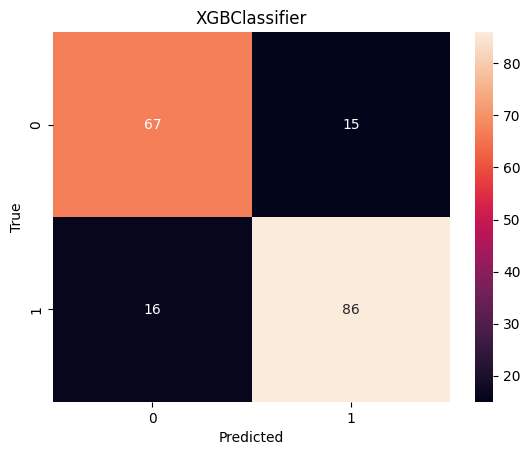

In [33]:

xgb_params = {'n_estimators': [50,100, 200],
              'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3,1.0],
              'max_depth': [1, 3, 5, 6,10,50],
              'subsample': [0.8, 1.0]}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_cv = GridSearchCV(xgb, xgb_params, cv=5, scoring='roc_auc', n_jobs=-1)
xgb_cv.fit(X_train, y_train)

print("Best params:", xgb_cv.best_params_)
xgb_best = xgb_cv.best_estimator_
xgb_metrics = eval_model(xgb_best, X_train, y_train, X_val, y_val)

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/tmp/ipykernel_48/2914280746.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


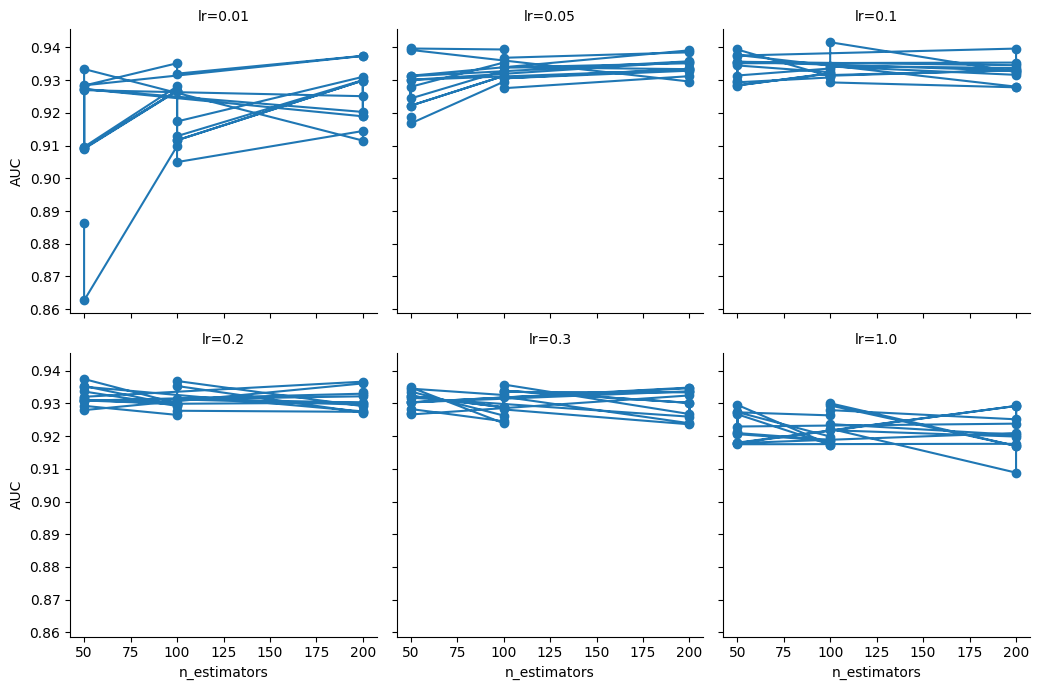

In [35]:
df_xgb = pd.DataFrame(xgb_cv.cv_results_)
g = sns.FacetGrid(df_xgb, col='param_learning_rate', col_wrap=3, height=3.5, sharey=True)
g.map_dataframe(
    lambda data, color: plt.plot(data['param_n_estimators'], data['mean_test_score'], color=color, marker='o')
)
g.set_axis_labels("n_estimators", "AUC")
g.set_titles("lr={col_name}")
plt.tight_layout()
plt.show()


In [36]:
results=pd.DataFrame([
    {'model':'LogisticRegression',**baseline_metrics},
    {'model':'DecisionTree',**dt_metrics},
    {'model':'RandomForest',**rf_metrics},
    {'model':'GradientBoosting',**gb_metrics},
    {'model':'XGBoost',**xgb_metrics},
])

In [37]:
results.sort_values('auc', ascending=False)

,model,acc,prec,rec,f1,auc
3,GradientBoosting,0.820652,0.855670,0.813725,0.834171,0.906444
2,RandomForest,0.815217,0.833333,0.833333,0.833333,0.900646
4,XGBoost,0.831522,0.851485,0.843137,0.847291,0.899570
0,LogisticRegression,0.798913,0.821782,0.813725,0.817734,0.896222
1,DecisionTree,0.842391,0.861386,0.852941,0.857143,0.875538


In [38]:
df_full_train=df_full_train.reset_index(drop=True)
y_full_train=df_full_train['heartdisease'].values
del df_full_train['heartdisease']

In [39]:
dv=DictVectorizer(sparse=False)

dict_full_train=df_full_train.to_dict(orient='records')
X_full_train=dv.fit_transform(dict_full_train)

dict_test=df_test.to_dict(orient='records')
X_test=dv.transform(dict_test)

In [40]:
final_model=XGBClassifier(
    learning_rate=xgb_cv.best_params_.get('learning_rate', 0.1),
    max_depth=xgb_cv.best_params_.get('max_depth', 3),
    n_estimators=xgb_cv.best_params_.get('n_estimators', 100),
    subsample=xgb_cv.best_params_.get('subsample', 1.0),
    min_child_weight=1,
    objective='binary:logistic',
    eval_metric='auc',
    nthread=8,
    random_state=1,
    use_label_encoder=False
)
# Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0
final_model.fit(X_full_train,y_full_train)
y_pred_test=final_model.predict(X_test)
y_proba_test=final_model.predict_proba(X_test)[:,1]

print("final Test AUC:",roc_auc_score(y_test,y_proba_test))
print(classification_report(y_test,y_pred_test))

final Test AUC: 0.9228837876614061
              precision    recall  f1-score   support

           0       0.86      0.87      0.86        82
           1       0.89      0.88      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184

